In [138]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

from pandas import read_csv, DataFrame, concat

from numpy import arange, full, nan, size, shape, pi, identity

from seaborn import heatmap

from os import path

from qiskit.circuit.library import z_feature_map, unitary_overlap, zz_feature_map
from qiskit.primitives import StatevectorSampler

# --- config ---

DATA_PATH = path.join('..', 'data', "water_potability.csv")
RANDOM_SEED = 42
CANTIDAD_MUESTRAS_ENTRENAMIENTO = 32
USAR_MATRICES_PRECOMPUTADAS = True

In [139]:
class Data():
    
    # --- data ---

    x = 0
    y = 0

    x_train = 0
    x_test = 0


    x_train_scaled = 0
    x_test_scaled = 0
    q_x_test_scaled = 0
    
    y_train = 0
    y_test = 0

    # --- svm

    svm = {}

    # --- qsvm

    qsvm = {}

    q_kernel = {}

    
    def getData(self):
        
        data = read_csv(DATA_PATH)
            
        data = data.dropna() # hay que limpiar los NaN, si no el normalizar no tiene sentido
        
        data = data.sample(frac=1,\
                           random_state=RANDOM_SEED)
        
        potable_data = data.loc[data['Potability']==1]
        
        unpotable_data = data.loc[data['Potability']==0]
        
        muestras = int((CANTIDAD_MUESTRAS_ENTRENAMIENTO/.8)/2)
        
        data = concat([potable_data.iloc[0:muestras], \
                       unpotable_data.iloc[0:muestras]])
        
        
        data = data.sample(frac = 1, \
                           random_state=RANDOM_SEED)
        
        '''
        
        Hay que ver si se ponen nuevas features
        
        '''
        
        '''
        El documento dice
        
        Imputar valores faltantes (pH: 491 NaN; Sulfato: 781 NaN; Trihalometanos: 162 NaN) por mediana por clase.
        
        Pero no sé si hay que hacer caso a eso xd
        
        '''
        
        potability = data["Potability"]
        
        data = data.drop("Potability", axis = 1) # quitar potabilidad

        self.x = data
        self.y = potability

    def proccess_data(self):
        
        data_train, data_test, potability_train, potability_test = \
        train_test_split(self.x, self.y, test_size=.2, random_state=RANDOM_SEED)
        
        #scaler = MinMaxScaler(feature_range=(0, 2 * pi))
        
        scaler = StandardScaler()
        
        data_train_scaled = scaler.fit_transform(data_train)
        data_test_scaled = scaler.transform(data_test)
        
        pca = PCA(n_components = 4, random_state=RANDOM_SEED)
        
        data_train_scaled = pca.fit_transform(data_train_scaled)
        
        data_test_scaled = pca.transform(data_test_scaled)

        self.x_train_scaled = data_train_scaled
        self.x_test_scaled = data_test_scaled
        self.y_train = potability_train 
        self.y_test = potability_test

    def generar_smv(self):

        x = self.x_train_scaled
        y = self.y_train

        scores = ["precision", "recall"]
        
        C = [10]
        
        gamma = ["scale"]
        
        tuned_parameters = [
            {"kernel": ["rbf"], "gamma": gamma, "C":C}
        ]
        
        def refit_strategy(cv_results):
        	
            cv_results_ = DataFrame(cv_results)
        
            best_index = cv_results_["mean_test_recall"].idxmax()
        
            return best_index
        
        grid_search = GridSearchCV(
            SVC(), tuned_parameters, scoring=scores, refit=refit_strategy, cv=5, n_jobs=-1
        )
        
        grid_search.fit(x, y)

        self.svm = grid_search

    def test(self, tipo):


        if tipo == 'c':
            
            x = self.x_test_scaled
            y = self.y_test
            svm = self.svm
        else:

            x = self.q_x_test_scaled
            y = self.y_test
            svm = self.qsvm

        y_pred = svm.predict(x)
        
        print(f'Confusion matrix: \n {confusion_matrix(y, y_pred)}\n')
        print(f'Accuracy = {accuracy_score(y, y_pred):.2f}')
        print(f'Clasification report: \n {classification_report(y, \
        y_pred, target_names=['Non-Potable' , 'Potable'])}')        

        print(f'Real y = {list(y)}')
        print(f'Prediction = {y_pred}')
        


    def generar_qsmv(self):

        # --- kernel matrix ---

        x_train = self.x_train_scaled

        y_train = self.y_train
        
        
        fm = zz_feature_map(feature_dimension = x_train.shape[1],\
                  #reps=2
                  )
        
        train_size = x_train.shape[0]
        
        kernel_matrix = identity(train_size)
        
        '''
        
        Esto es llenar la matriz de kernel con las mediciones del producto interno para ver qué tanto comparten 2 datos
        
        Se tiene una diagonal de 1's puesto que el producto interno consigo mismo es 1
        
        Esta forma ese más efectiva que hacer el cálculo completo, por el gran tamaño de la matriz
        
        '''
        
        sampler = StatevectorSampler(seed = RANDOM_SEED)
        num_shots = 100
        
        for x1 in range(0, train_size):
            for x2 in range(x1 + 1, train_size):
                unitary1 = fm.assign_parameters(x_train[x1])
                unitary2 = fm.assign_parameters(x_train[x2])
        
                # Create the overlap circuit
                overlap_circ = unitary_overlap(unitary1, unitary2)
                overlap_circ.measure_all()
        
                # These lines run the qiskit sampler primitive.
                counts = (
                    sampler.run([overlap_circ], shots=num_shots)
                    .result()[0]
                    .data.meas.get_int_counts()
                )
        
                # Assign the probability of the 0 state to the kernel matrix, and the transposed element
                # (since this is an inner product)
                kernel_matrix[x1, x2] = counts.get(0, 0.0) / num_shots
                kernel_matrix[x2, x1] = counts.get(0, 0.0) / num_shots
            # Fill in on-diagonal elements with 1, again, since this is an inner-product corresponding to
            # probability (or alter the code to check these entries and verify they yield 1)
            kernel_matrix[x1, x1] = 1

        # --- test matrix ---

        x_test = self.x_test_scaled
            
        test_size = shape(x_test)[0]
        
        '''
        La matriz de prueba tiene forma test x train, ya que me da la relación entre los datos nuevos y los datos utilizados para el entrenamiento
        '''
        
        test_matrix = full((test_size, train_size), nan)
        
        for x1 in range(0, test_size):
            for x2 in range(0, train_size):
                unitary1 = fm.assign_parameters(x_test[x1])
                unitary2 = fm.assign_parameters(x_train[x2])
        
                # Create the overlap circuit
                overlap_circ = unitary_overlap(unitary1, unitary2)
                overlap_circ.measure_all()
        
                # These lines run the qiskit sampler primitive.
                counts = (
                    sampler.run([overlap_circ], shots=num_shots)
                    .result()[0]
                    .data.meas.get_int_counts()
                )
        
                # Assign the probability of the 0 state to the kernel matrix, and the transposed element
                # (since this is an inner product)
                test_matrix[x1, x2] = counts.get(0, 0.0) / num_shots

        qsvm = SVC(kernel='precomputed')

        qsvm.fit(kernel_matrix, y_train)

        self.q_kernel = kernel_matrix
        self.q_x_test_scaled = test_matrix
        self.qsvm = qsvm

# Data

## Get data

In [140]:
data = Data()

data.getData()

## Pre-proccess data

In [141]:
data.proccess_data()

# SVM

In [142]:
data.generar_smv()

# Test

In [143]:
data.test(tipo = 'c')

Confusion matrix: 
 [[2 1]
 [4 1]]

Accuracy = 0.38
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.33      0.67      0.44         3
     Potable       0.50      0.20      0.29         5

    accuracy                           0.38         8
   macro avg       0.42      0.43      0.37         8
weighted avg       0.44      0.38      0.35         8

Real y = [0, 1, 1, 0, 1, 1, 1, 0]
Prediction = [1 0 0 0 1 0 0 0]


In [144]:
#results = DataFrame(grid_search.cv_results_)
#
#
#results.to_csv("laMambaNegra.csv")
#
#print(f'Best params: {grid_search.best_params_}')
#
#results[
#[
#"param_C",
#"param_gamma",
#"mean_test_precision",
#"mean_test_recall",
#]
#]

In [145]:
#heatmap(data.corr(), \
#			 annot=True, \
#			 robust=True, \
#			 vmin= -1, \
#			 vmax= 1)

# QSVM

## Quantum Kernel

In [146]:
data.generar_qsmv()

## Test QSVM

In [147]:
data.test(tipo = 'q')

Confusion matrix: 
 [[3 0]
 [4 1]]

Accuracy = 0.50
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.43      1.00      0.60         3
     Potable       1.00      0.20      0.33         5

    accuracy                           0.50         8
   macro avg       0.71      0.60      0.47         8
weighted avg       0.79      0.50      0.43         8

Real y = [0, 1, 1, 0, 1, 1, 1, 0]
Prediction = [0 0 0 0 1 0 0 0]


In [148]:
import numpy as np
off_diag = data.q_kernel[~np.eye(data.q_kernel.shape[0], dtype=bool)]
print(f"Media: {off_diag.mean():.4f}, Std: {off_diag.std():.4f}")
print(f"Min: {off_diag.min():.4f}, Max: {off_diag.max():.4f}")

Media: 0.0603, Std: 0.0645
Min: 0.0000, Max: 0.3300


<Axes: >

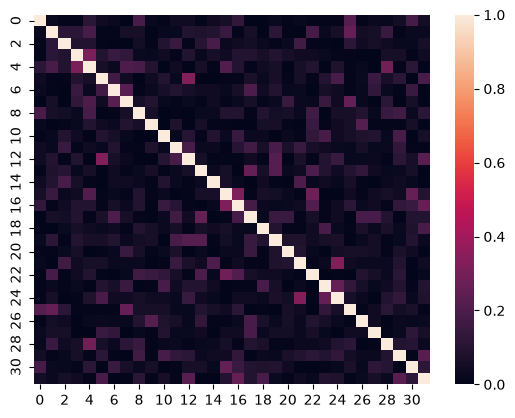

In [149]:
heatmap(data.q_kernel) #vmax= 1, vmin=-1)